In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import os

from sksurv.nonparametric import kaplan_meier_estimator

# for now I will just use the forest model from scikit-survival
from sksurv.ensemble import RandomSurvivalForest
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sksurv.datasets import load_gbsg2
from sksurv.ensemble import RandomSurvivalForest
from sksurv.preprocessing import OneHotEncoder
from sksurv.util import Surv


## GSE30929

In [2]:
#load separate GEO datasets
gse21050 = GEOparse.get_GEO(geo="GSE21050", destdir="./data", silent=True)
gse30929 = GEOparse.get_GEO(geo="GSE30929", destdir="./data", silent=True)
gse71118 = GEOparse.get_GEO(geo="GSE71118", destdir="./data", silent=True)


c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


In [8]:
# get all the metadata
metadata21050 = gse21050.phenotype_data
metadata30929 = gse30929.phenotype_data
metadata71118 = gse71118.phenotype_data


#print the columns of each metadata
#and save as csv for ease of access later
print("Metadata Columns:")
print("GSE21050:")
print(metadata21050.columns)
metadata21050.to_csv("./data/metadata21050.csv")

print("GSE30929:")
print(metadata30929.columns)
metadata30929.to_csv("./data/metadata30929.csv")

print("GSE71118:")
print(metadata71118.columns)
metadata71118.to_csv("./data/metadata71118.csv")

Metadata Columns:
GSE21050:
Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.cohort',
       'characteristics_ch1.1.tissue', 'characteristics_ch1.2.cinsarc group',
       'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time',
       'characteristics_ch1.5.diagnosis', 'treatment_protocol_ch1',
       'molecule_ch1', 'extract_protocol_ch1', 'label_ch1',
       'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description',
       'data_processing', 'platform_id', 'contact_name', 'contact_email',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count', 'characteristics_ch1.3.diagnosis'],
      dtype='object')
GSE30929:
Index(['title', 'geo_accession', '

In [9]:
#keep relevant columns for analysis
#this will be geo_accession, metastasis status, time, and cancer type/diagnosis
# in GSE30929, distant recurrence-free survival (DRFS) is used instead of metastasis
cols_keep_21050 = ['geo_accession','characteristics_ch1.5.diagnosis', 'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time']
cols_keep_30929 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.4.drfs', 'characteristics_ch1.5.tt.drfs']
cols_keep_71118 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.0.metastasis', 'characteristics_ch1.1.time' ]

col_names = ['geo_accession','cancer_type','metastasis_status','time']
# combine all metadata into one dataframe
#this looks a little intense, but it's just renaming columns and concatenating dataframes
metadata = pd.concat([metadata21050[cols_keep_21050].rename(columns=dict(zip(cols_keep_21050, col_names))),
                    metadata30929[cols_keep_30929].rename(columns=dict(zip(cols_keep_30929, col_names))),
                    metadata71118[cols_keep_71118].rename(columns=dict(zip(cols_keep_71118, col_names)))], 
                    keys=['GSE21050','GSE30929','GSE71118']).reset_index(level=0).rename(columns={'level_0':'dataset'})
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
GSM525806,GSE21050,GSM525806,Liposarcoma - dedifferentiated,no,9
GSM525807,GSE21050,GSM525807,Leiomyosarcoma,yes,1.22
GSM525808,GSE21050,GSM525808,Undifferentiated sarcoma,yes,0.92
GSM525809,GSE21050,GSM525809,Other,yes,1.48
GSM525810,GSE21050,GSM525810,Undifferentiated sarcoma,no,0.21


In [10]:
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [11]:
#remove missing data
metadata = metadata.dropna()
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [12]:
# keep only data with liposarcoma
sarcoma_list = ['Liposarcoma - dedifferentiated',
 'liposarcoma, dedifferentiated',
 'liposarcoma, myxoid/round cell',
 'liposarcoma, myxoid',
 'liposarcoma, pleomorphic',
 'liposarcoma, well-differentiated',
 'Dedifferentiated liposarcoma',
 'Liposarcoma']

metadata = metadata[metadata.cancer_type.isin(sarcoma_list)]

metadata.cancer_type.value_counts()

cancer_type
Liposarcoma - dedifferentiated      62
liposarcoma, well-differentiated    52
Dedifferentiated liposarcoma        44
liposarcoma, dedifferentiated       40
liposarcoma, pleomorphic            20
liposarcoma, myxoid                 17
liposarcoma, myxoid/round cell      11
Liposarcoma                          1
Name: count, dtype: int64

In thier study they use 192 samples, where as the full list is 247. Im wondering if during batch correction they removed 55?

In [47]:
#need to standardize metastasis status values
metadata.metastasis_status.value_counts()

metastasis_status
False    170
True      77
Name: count, dtype: int64

In [46]:
metastasis_map = {
    'FALSE': False,
    'TRUE': True,
    'no': False,
    'yes': True,
    'No': False,
    'yes': True,
    'Yes': True
    }
metadata['metastasis_status'] = metadata['metastasis_status'].map(metastasis_map)

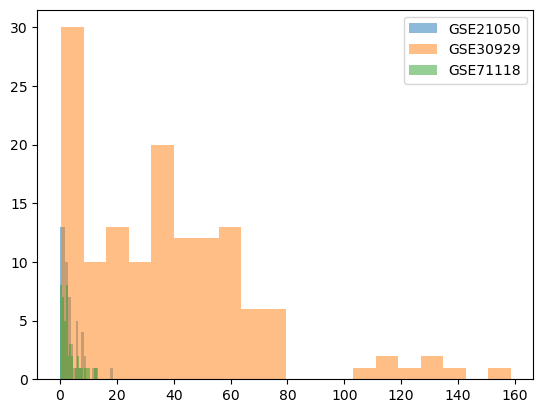

In [ ]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.show()

In [51]:
#convert GSE30950 time to years
metadata.loc[metadata['dataset']=='GSE30929', 'time'] = metadata.loc[metadata['dataset']=='GSE30929', 'time'] / 12

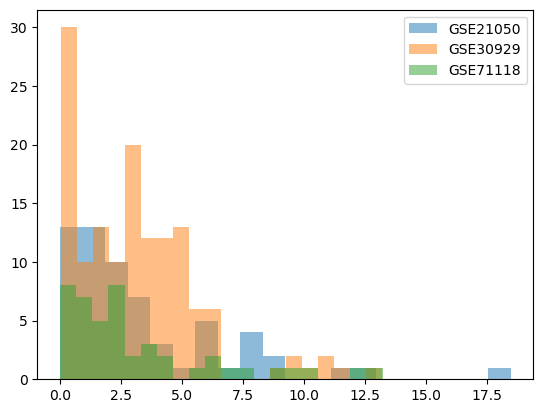

In [52]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.show()

In [53]:
#save combined metadata to csv
metadata.to_csv("./data/combined_metadata.csv", index=False)

# Combining data

In [3]:
table21050 = gse21050.pivot_samples('VALUE')
table30929 = gse30929.pivot_samples('VALUE')
table71118 = gse71118.pivot_samples('VALUE')
#combine expression data
expression_data = pd.concat([np.log2(table21050+1), table30929, table71118], axis=1, join='inner')
expression_data.shape

(22215, 762)

<Axes: xlabel='name'>

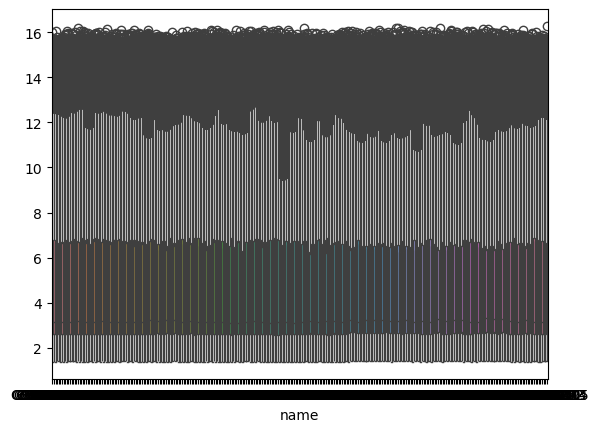

In [27]:
sns.boxplot(data=np.log2(table21050+1))

<Axes: xlabel='name'>

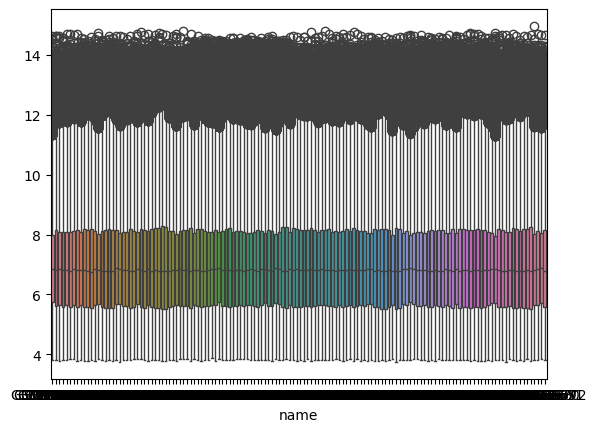

In [26]:
sns.boxplot(data=table30929)

In [8]:
# keep only liposarcoma samples in expression data
expression_data = expression_data[metadata['geo_accession']]
expression_data.shape

(22215, 247)

In [9]:
#save combined expression data to csv
expression_data.to_csv("./data/combined_expression_data_unscaled.csv", index=True)


In [47]:
#load expression data
expression_data = pd.read_csv("./data/combined_expression_data_unscaled.csv", index_col=0)
metadata = pd.read_csv("./data/combined_metadata.csv")

(22215, 248)

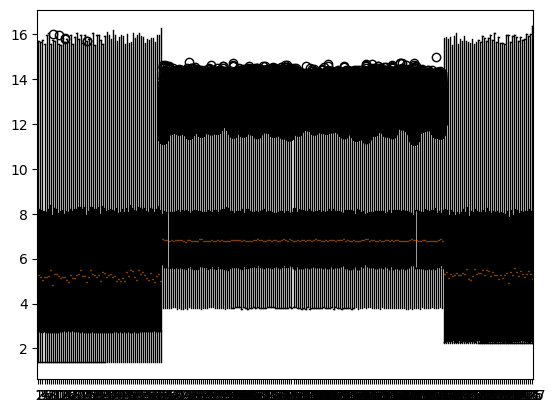

In [48]:
plot = plt.boxplot(expression_data)

In [49]:
metadata.head()
# Convert the 'color' column to a 'category' dtype
dataset_map = {
    'GSE21050': 0,
    'GSE30929': 1,
    'GSE71118': 2
}
batch = metadata['dataset'].map(dataset_map)


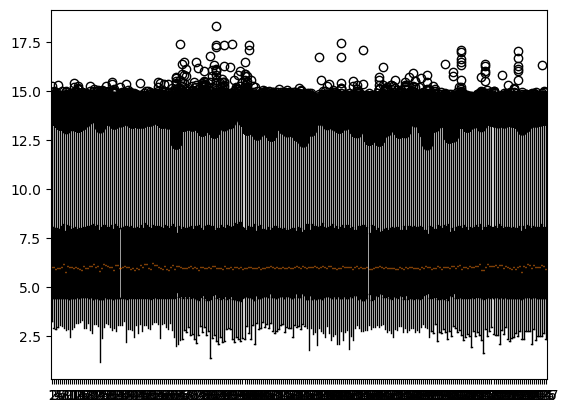

In [50]:
# normalize expression data
from inmoose.pycombat import pycombat_norm


# run pycombat_norm
df_corrected = pycombat_norm(expression_data, batch)

# visualize results
plt.boxplot(df_corrected)
plt.show()

In [52]:
#save scaled data
df_corrected.to_csv("./data/combined_expression_data_scaled.csv", index=True)

In [53]:
#load scaled data
df_corrected = pd.read_csv("./data/combined_expression_data_scaled.csv", index_col=0)

In [16]:
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
0,GSE21050,GSM525806,Liposarcoma - dedifferentiated,False,9.00
1,GSE21050,GSM525811,Liposarcoma - dedifferentiated,True,0.95
2,GSE21050,GSM525812,Liposarcoma - dedifferentiated,True,0.87
3,GSE21050,GSM525814,Liposarcoma - dedifferentiated,False,2.84
4,GSE21050,GSM525818,Liposarcoma - dedifferentiated,False,4.04


Text(0.5, 0, 'time $t$')

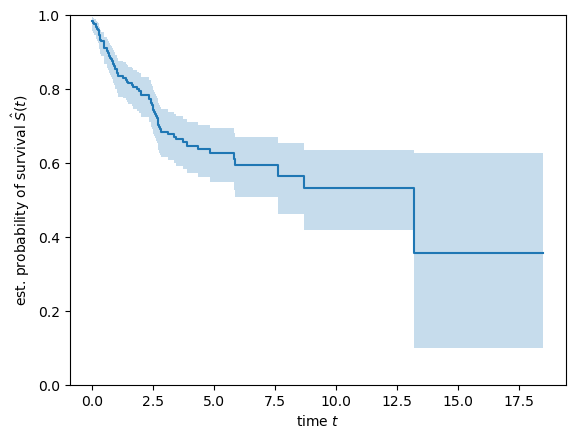

In [17]:
# make a simple survival analysis dataframe

time, survival_prob, conf_int = kaplan_meier_estimator(
    metadata['metastasis_status'], metadata['time'], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

# survival model

In [ ]:


set_config(display="text")  # displays text representation of estimators

In [20]:
y = Surv.from_arrays(event=metadata['metastasis_status'], time=metadata['time'])
X = df_corrected.transpose()

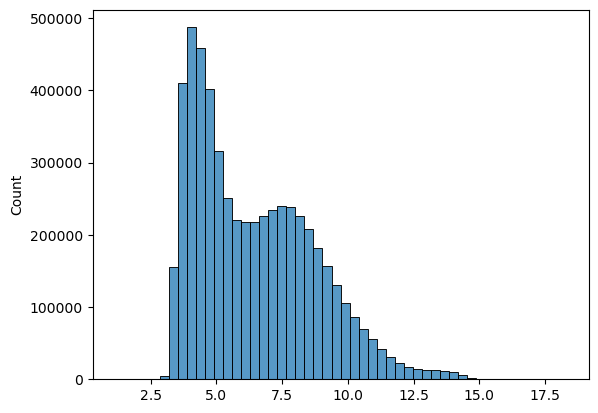

In [21]:
plot = sns.histplot(X.values.flatten(), bins=50)

In [22]:



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, train_size=0.2, random_state=42
)

In [3]:
from sklearn.preprocessing import StandardScaler

In [47]:
#skip scalling as we already did?

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
# Initialize and fit Random Survival Forest
rsf = RandomSurvivalForest(
    n_estimators=100,           # Number of trees
    min_samples_split=10,       # Minimum samples to split a node
    min_samples_leaf=5,         # Minimum samples in a leaf
    max_features='sqrt',        # Number of features to consider for splitting
    n_jobs=-1,                  # Use all available cores
    random_state=42
)

In [48]:
print("Fitting Random Survival Forest...")
rsf.fit(X_train_scaled, y_train)

# Evaluate model performance (C-index)
train_score = rsf.score(X_train_scaled, y_train)
test_score = rsf.score(X_test_scaled, y_test)
print(f"\nModel Performance (C-index):")
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")



Fitting Random Survival Forest...

Model Performance (C-index):
Training score: 0.9598
Testing score: 0.6371


In [ ]:
# get feature importances
# rsf.feature_importances_ is not implemented for RandomSurvivalForest
# they suggest using permutation importance instead
from sklearn.inspection import permutation_importance

result = permutation_importance(rsf, X_test_scaled_mini, y_test, n_repeats=15, random_state=42)

In [ ]:
pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns[0:50],
).sort_values(by="importances_mean", ascending=False)

C-index = 1.0: Perfect prediction - the model always correctly orders patients by risk
C-index = 0.5: Random prediction - no better than flipping a coin
C-index = 0.0: Perfect inverse prediction - the model gets the ordering completely backwards

In [ ]:
from sksurv.linear_model import CoxPHSurvivalAnalysis

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = np.empty(n_features)
    # Fit a CoxPH model for each feature
    for j in range(n_features):
        Xj = X.iloc[:, j : j + 1] # Select one feature
        try:
            m = CoxPHSurvivalAnalysis()
            m.fit(Xj, y)
            scores[j] = m.score(Xj, y) # Use concordance index as the score
        except Exception as e:
            scores[j] = 0.0
    return scores
feature_scores = fit_and_score_features(X_train_scaled, y_train)

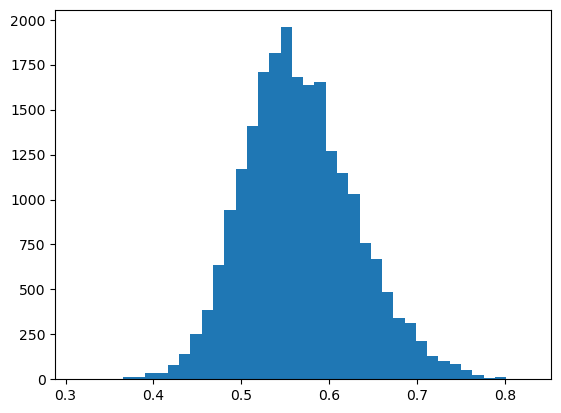

In [27]:
plot = plt.hist(feature_scores, bins=40)

In [28]:
# add feature score to table
#table['feature_score'] = feature_scores
feature_names = X.columns

score_df = pd.DataFrame({'id': feature_names, 'c-index_score': feature_scores})
score_df.head()

,id,c-index_score
0,1007_s_at,0.496982
1,1053_at,0.644869
2,117_at,0.597586
3,121_at,0.486922
4,1255_g_at,0.466801


In [41]:
#get the platform annotations
#unshown but gse21050 has no unique ids compared to the other two
gene_info = gse21050.gpls['GPL570'].table

#merge feature scores with gene info
merged_scores = pd.merge(score_df, gene_info, left_on='id', right_on='ID', how='left')

#save merged scores
merged_scores.to_csv("./data/feature_scores_with_annotations.csv", index=False)





In [40]:
#check for specific genes from paper
genes_of_interest = ['CDH3', 'ADORA2B', 'MMP14', 'IP6K2', 'HTR2A']
merged_scores[merged_scores['Gene Symbol'].isin(genes_of_interest)][['id','Gene Symbol', 'c-index_score']]

,id,Gene Symbol,c-index_score
14,160020_at,MMP14,0.661972
2354,202827_s_at,MMP14,0.653924
2355,202828_s_at,MMP14,0.668008
2782,203256_at,CDH3,0.619718
5417,205891_at,ADORA2B,0.684105
6660,207135_at,HTR2A,0.564386
11020,211616_s_at,HTR2A,0.577465
16643,217279_x_at,MMP14,0.634809
17556,218192_at,IP6K2,0.545272


# Testing multiple models
Want to test 
* lasso
* random forest (RSF)
* plsRcox
* stepCox
* CoxBoost
* Enet [0.1:0.8]
* GBM
* SVM


In [56]:
from survival_functions import *
pipeline = SurvivalModelPipeline(random_state=42)
pipeline.load_and_prepare_data(X=X_train, y=y_train)


Training samples: 34
Testing samples: 15
Features: 22215


In [57]:
pipeline.train_and_evaluate()


Training and Evaluating Models

CoxPH:
----------------------------------------
  Error: Unable to allocate 3.68 GiB for an array with shape (22215, 22215) and data type float64

CoxNet:
----------------------------------------
  Error: no field of name cens

RSF:
----------------------------------------
  Error: no field of name cens

GradientBoosting:
----------------------------------------
  Error: no field of name cens

SurvivalSVM:
----------------------------------------
  Error: no field of name cens


In [44]:
from sksurv.datasets import load_gbsg2
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM

In [ ]:
random_state = 42
models = {
    'CoxPH': CoxPHSurvivalAnalysis(),
    'CoxNet': CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01, 
                                        max_iter=100),
    'RSF': RandomSurvivalForest(n_estimators=100, 
                                min_samples_split=10,
                                min_samples_leaf=15,
                                max_features="sqrt",
                                random_state=random_state),
    'GradientBoosting': GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=random_state
    ),
    'SurvivalSVM': FastSurvivalSVM(max_iter=100, random_state=random_state)
    }

# MIC

In [24]:
expression_data = pd.read_csv('data/combined_expression_data_scaled.csv')
metadata = pd.read_csv('data/combined_metadata.csv')
mic_data = pd.read_csv('data/mic/mic_c.csv', header=None)
gene_feature_scores = pd.read_csv('data/feature_scores_with_annotations.csv')

In [25]:
#add column names to mic_data
mic_data.columns = ['mic_metastasis_status', 'mic_time']

In [55]:
mic_data['gene'] = gene_feature_scores['Gene Symbol']
mic_data['sum_mic'] = mic_data['mic_metastasis_status'] + mic_data['mic_time']
mic_data['id'] = gene_feature_scores['id']
mic_data.head()

,mic_metastasis_status,mic_time,gene,sum_mic,id
0,0.017488,0.022323,DDR1 /// MIR4640,0.039811,1007_s_at
1,0.049804,0.040806,RFC2,0.090610,1053_at
2,0.006658,0.026787,HSPA6,0.033446,117_at
3,0.024633,0.040310,PAX8,0.064943,121_at
4,0.021570,0.019469,GUCA1A,0.041039,1255_g_at


In [32]:
genes_of_interest = ['CDH3', 'ADORA2B', 'MMP14', 'IP6K2', 'HTR2A']

#check mic values for genes of interest
mic_data[mic_data['gene'].isin(genes_of_interest)]

,mic_metastasis_status,mic_time,gene,sum_mic
14,0.104732,0.083778,MMP14,0.188510
2354,0.094205,0.070364,MMP14,0.164570
2355,0.113648,0.097957,MMP14,0.211605
2782,0.075310,0.024711,CDH3,0.100022
5417,0.037770,0.064652,ADORA2B,0.102422
6660,0.022466,0.054087,HTR2A,0.076554
11020,0.034916,0.034672,HTR2A,0.069588
16643,0.089973,0.057173,MMP14,0.147146
17556,0.028916,0.034551,IP6K2,0.063467


## should probobly only look at metastasis

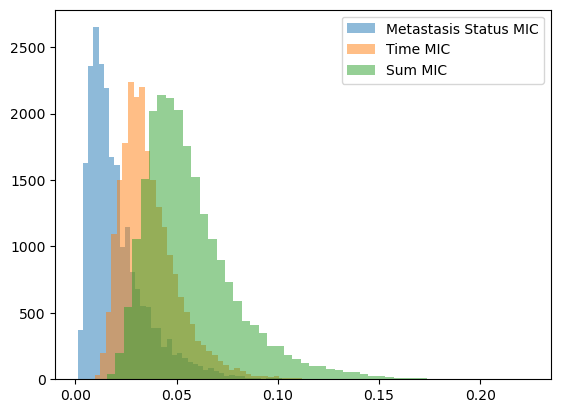

In [34]:
# make histogram of mic values
plt.hist(mic_data['mic_metastasis_status'], bins=50, alpha=0.5, label='Metastasis Status MIC')
plt.hist(mic_data['mic_time'], bins=50, alpha=0.5, label='Time MIC')
plt.hist(mic_data['sum_mic'], bins=50, alpha=0.5, label='Sum MIC')
plt.legend()
plt.show()

In [57]:
# get the top 20% of genes by mic
top_20_percent_threshold = mic_data['sum_mic'].quantile(0.8)
top_genes = mic_data[mic_data['sum_mic'] >= top_20_percent_threshold]['gene']
top_ids = mic_data[mic_data['sum_mic'] >= top_20_percent_threshold]['id']
print("choosing ", len(top_genes), "out of ", len(mic_data), " genes as top 20% by MIC")


choosing  4443 out of  22215  genes as top 20% by MIC


In [58]:
# filter expression data to only include top genes by mic
expression_data_top_genes = expression_data[expression_data.index.isin(top_ids)]
expression_data_top_genes.shape

(4443, 247)

In [59]:
# save expression data with only top genes by mic
expression_data_top_genes.to_csv('./data/combined_expression_data_top20_mic.csv', index=True)

# retry fitting with top genes

In [2]:
#load data
expression_data_top_genes = pd.read_csv('./data/combined_expression_data_top20_mic.csv', index_col=0)
metadata = pd.read_csv('data/combined_metadata.csv')

In [6]:
# reimport survival functions
from importlib import reload

import survival_functions
reload(survival_functions)

<module 'survival_functions' from 'c:\\Users\\sherh\\Documents\\bf550\\BF550_final_project\\survival_functions.py'>

In [7]:
from survival_functions import *
y = Surv.from_arrays(event=metadata['metastasis_status'], time=metadata['time'])
X = expression_data_top_genes.T

pipeline = SurvivalModelPipeline(random_state=42)
pipeline.load_and_prepare_data(X=X, y=y)

pipeline.train_and_evaluate()

Training samples: 172
Testing samples: 75
Features: 4443

Training and Evaluating Models

CoxLasso:
----------------------------------------
  Fitting model... CoxLasso
  Predicting risk scores... CoxLasso
  Calculating C-index... CoxLasso
  Could not calculate IBS: Input estimate contains infinity or a value too large for dtype('float64').
  C-index: 0.7403
  Mean AUC: 0.7716

CoxElasticNet:
----------------------------------------
  Fitting model... CoxElasticNet
  Predicting risk scores... CoxElasticNet
  Calculating C-index... CoxElasticNet
  Could not calculate AUC: `fit` must be called with the fit_baseline_model option set to True.
  Could not calculate IBS: `fit` must be called with the fit_baseline_model option set to True.
  C-index: 0.7337

RSF:
----------------------------------------
  Fitting model... RSF
  Predicting risk scores... RSF
  Calculating C-index... RSF
  C-index: 0.7514
  Mean AUC: 0.7962
  IBS: 0.1251


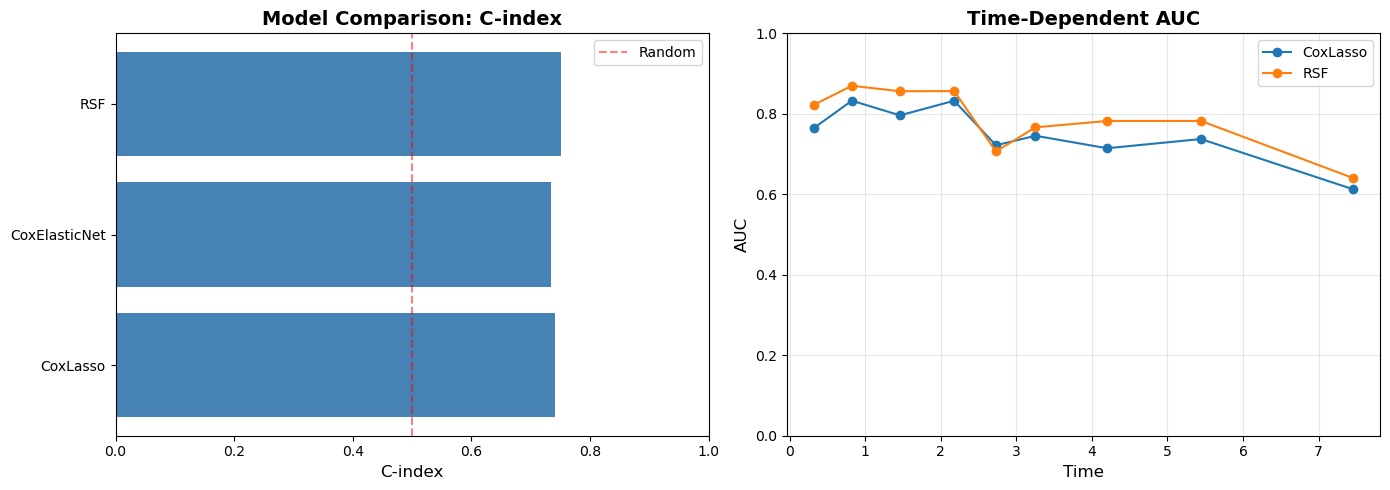


Summary Results
        Model  C-index  Mean AUC     IBS
          RSF 0.751381  0.796194 0.12507
     CoxLasso 0.740331  0.771601     NaN
CoxElasticNet 0.733702       NaN     NaN

Best model by C-index: RSF


In [8]:
pipeline.plot_results()
    
# Print summary table
print("\n" + "="*60)
print("Summary Results")
print("="*60)
summary = pipeline.get_summary()
print(summary.to_string(index=False))

# Get best model
best_model_name = summary.iloc[0]['Model']
print(f"\nBest model by C-index: {best_model_name}")

In [9]:
rsf = pipeline.models['RSF']

In [22]:
#extract feature importances using permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(rsf, 
                                pipeline.X_test, 
                                pipeline.y_test, n_repeats=10, random_state=42)

In [28]:
result = permutation_importance(rsf, 
                                pipeline.X_test[0:30], 
                                pipeline.y_test[0:30], n_repeats=10, random_state=42)

In [29]:
result_df = pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=pipeline.X_test.columns,
).sort_values(by="importances_mean", ascending=False)

result_df.sort_values(by="importances_mean", ascending=False).head(20)

,importances_mean,importances_std
ID_REF,,
200039_s_at,0.0,0.0
91952_at,0.0,0.0
1053_at,0.0,0.0
1294_at,0.0,0.0
1487_at,0.0,0.0
160020_at,0.0,0.0
200000_s_at,0.0,0.0
200004_at,0.0,0.0
200012_x_at,0.0,0.0


In [ ]:
lasso =pipeline.models['CoxLasso']

lasso.

array([[0.        , 0.        , 0.        , ..., 1.02971163, 1.02584856,
        1.0237683 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(4443, 100))

# Next steps
* run random forest on selected genes